# **Credit Card Approval Prediction**

## import libraries

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier



import joblib

## Load the Datasets

In [4]:
application = pd.read_csv("data/application_record.csv")
credit = pd.read_csv("data/credit_record.csv")

Display First Five Rows

In [5]:
application.head()

credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


Understand the Dataset Structure

In [6]:
print("Application Shape :", application.shape)
print("Credit Shape :", credit.shape)


application.info()

credit.info()

Application Shape : (438557, 18)
Credit Shape : (1048575, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PH

## Data Cleaning

In [ ]:
# Create copies of the original datasets

clean_application = application.copy()
clean_credit = credit.copy()


# Missing values in application dataset

application_missing = clean_application.isnull().sum()
application_missing = application_missing[application_missing > 0]

application_missing

# Missing values in credit dataset

credit_missing = clean_credit.isnull().sum()
credit_missing = credit_missing[credit_missing > 0]

credit_missing


## Check Duplicate Records

clean_application.duplicated().sum()
clean_credit.duplicated().sum()


## Remove Duplicate Records

clean_application = clean_application.drop_duplicates()

clean_credit = clean_credit.drop_duplicates()


# Verify duplicates after removal

print("Application Dataset Duplicates :", clean_application.duplicated().sum())
print("Credit Dataset Duplicates      :", clean_credit.duplicated().sum())





clean_application.dtypes

clean_credit.dtypes

clean_application.info()

clean_credit.info()

categorical_columns = clean_application.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{'='*50}")
    print(f"Column: {column}")
    print(f"Number of Unique Values: {clean_application[column].nunique()}")
    print(clean_application[column].unique())




for column in clean_credit.columns:
    print(f"\n{'='*50}")
    print(f"Column: {column}")
    print(f"Number of Unique Values: {clean_credit[column].nunique()}")
    print(clean_credit[column].unique())

Application Dataset Duplicates : 0
Credit Dataset Duplicates      : 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14

## Data Merging

* ### **Create Target Variable from Credit History**

In [8]:
credit["TARGET"] = credit["STATUS"].apply(
    lambda x: 1 if x in ["1","2","3","4","5"] else 0
)

* ### **Create One Target per Customer**

In [9]:
credit_target = (
    credit.groupby("ID")["TARGET"]
    .max()
    .reset_index()
)

* ###  **Merge Application and Credit Records**

In [10]:
final_df = clean_application.merge(
    credit_target,
    on="ID",
    how="inner"
)

* ### **Display Merged Dataset**

In [11]:
final_df.head()
print("Final Dataset Shape:", final_df.shape)

final_df.info()

final_df.columns

## Check Target Distribution

final_df["TARGET"].value_counts()

final_df["TARGET"].value_counts(normalize=True) * 100

Final Dataset Shape: (36457, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLA

TARGET
0    88.22997
1    11.77003
Name: proportion, dtype: float64

# Exploratory Data Analysis (EDA)

In [12]:
## Dataset Overview

print("Number of Rows    :", final_df.shape[0])
print("Number of Columns :", final_df.shape[1])

final_df.head()
final_df.info()

final_df.describe().T
final_df.describe(include="object").T

## Missing Values Analysis


# Count missing values in each column

final_df.isnull().sum()

# Display only columns with missing values

missing_values = final_df.isnull().sum()
missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)


# Calculate missing value percentage

missing_percentage = (
    final_df.isnull().sum() / len(final_df)
) * 100

missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage.sort_values(ascending=False)



# Count duplicate rows

duplicate_count = final_df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)


## Target Variable Distribution

# Count of each target class

final_df["TARGET"].value_counts()


# Percentage distribution of target classes

(final_df["TARGET"].value_counts(normalize=True) * 100).round(2)

Number of Rows    : 36457
Number of Columns : 19
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  

TARGET
0    88.23
1    11.77
Name: proportion, dtype: float64

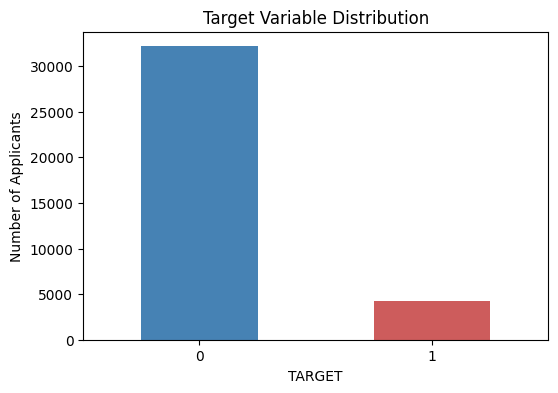

In [13]:
# Visualize target distribution

plt.figure(figsize=(6,4))

final_df["TARGET"].value_counts().plot(
    kind="bar",
    color=["steelblue", "indianred"]
)

plt.title("Target Variable Distribution")
plt.xlabel("TARGET")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)

plt.show()

In [14]:
## Feature Engineering for Numerical Analysis

# Convert age from days to years

final_df["Age"] = (-final_df["DAYS_BIRTH"] / 365).astype(int)




# Convert employment duration from days to years

final_df["Employment_Years"] = (
    final_df["DAYS_EMPLOYED"]
    .replace(365243, np.nan)   # Replace anomalous value with NaN
)

final_df["Employment_Years"] = (
    -final_df["Employment_Years"] / 365
).round(1)


## Verify Newly Created Features


final_df[[
    "DAYS_BIRTH",
    "Age",
    "DAYS_EMPLOYED",
    "Employment_Years"
]].head()

,DAYS_BIRTH,Age,DAYS_EMPLOYED,Employment_Years
0,-12005,32,-4542,12.4
1,-12005,32,-4542,12.4
2,-21474,58,-1134,3.1
3,-19110,52,-3051,8.4
4,-19110,52,-3051,8.4


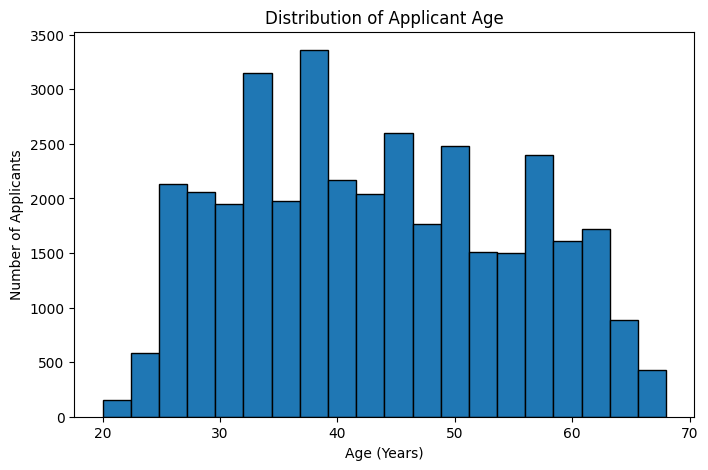

In [15]:
## Age Distribution

final_df["Age"].describe()

plt.figure(figsize=(8,5))

plt.hist(final_df["Age"], bins=20, edgecolor="black")

plt.title("Distribution of Applicant Age")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Applicants")

plt.show()



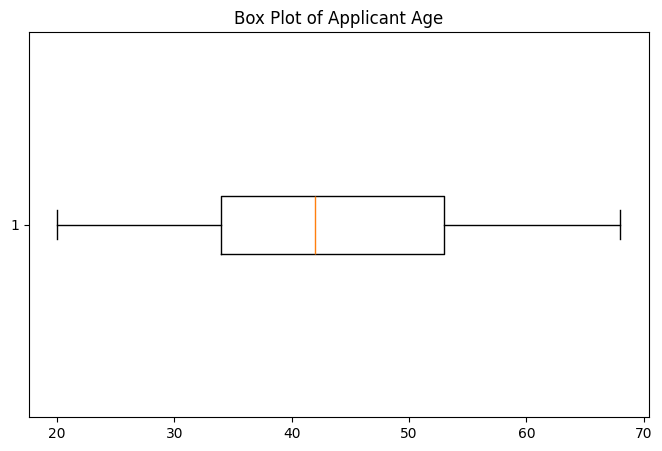

In [16]:
plt.figure(figsize=(8,5))

plt.boxplot(final_df["Age"], vert=False)

plt.title("Box Plot of Applicant Age")

plt.show()

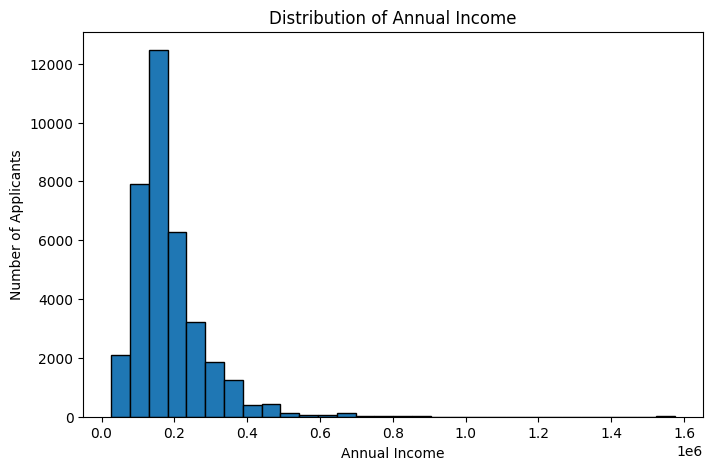

In [17]:
## Annual Income Analysis

# Summary statistics of annual income

final_df["AMT_INCOME_TOTAL"].describe()

# Histogram of annual income

plt.figure(figsize=(8,5))

plt.hist(final_df["AMT_INCOME_TOTAL"], bins=30, edgecolor="black")

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Number of Applicants")

plt.show()

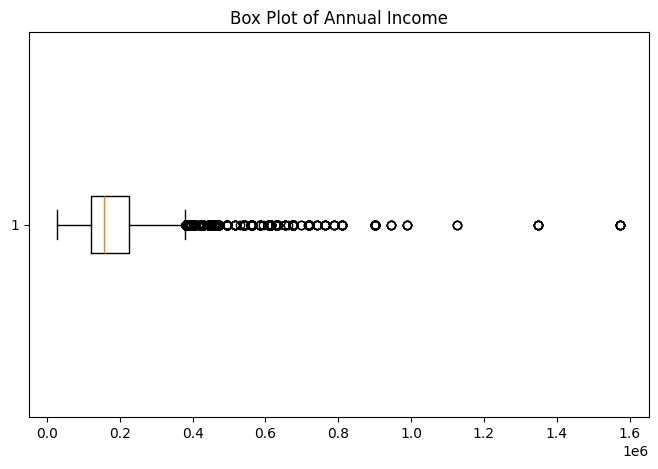

In [18]:
# Box plot of annual income

plt.figure(figsize=(8,5))

plt.boxplot(final_df["AMT_INCOME_TOTAL"], vert=False)

plt.title("Box Plot of Annual Income")

plt.show()

In [19]:
# Annual income grouped by target

final_df.groupby("TARGET")["AMT_INCOME_TOTAL"].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,32166.0,185785.986150,99639.776192,27000.0,121500.0,157500.0,225000.0,1575000.0
1,4291.0,193430.405733,116439.227367,27000.0,126000.0,171000.0,225000.0,1575000.0


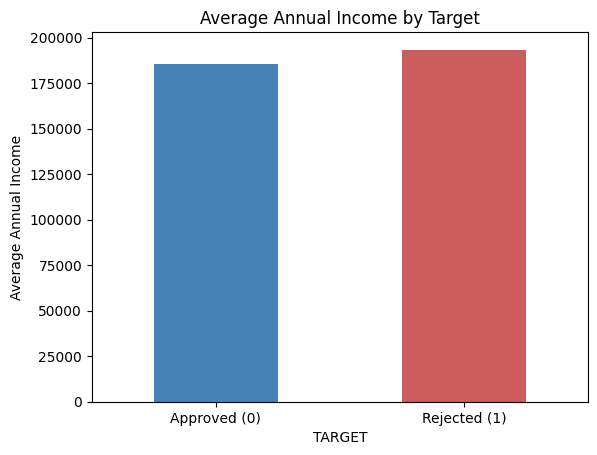

In [20]:
# Average annual income by target

final_df.groupby("TARGET")["AMT_INCOME_TOTAL"].mean().plot(
    kind="bar",
    color=["steelblue", "indianred"]
)

plt.title("Average Annual Income by Target")
plt.xlabel("TARGET")
plt.ylabel("Average Annual Income")
plt.xticks([0,1], ["Approved (0)", "Rejected (1)"], rotation=0)

plt.show()

* ### **Numerical Feature Analysis**

To avoid repetitive code, a reusable function is created for analyzing numerical features. The function displays:

- Summary Statistics
- Histogram
- Box Plot
- Target-wise Summary Statistics
- Average Value by Target

This ensures a consistent analysis for all numerical variables.

In [21]:
def analyze_numerical_feature(data, column):

    print("=" * 70)
    print(f"Feature : {column}")
    print("=" * 70)

    # Summary Statistics
    print("\nSummary Statistics")
    display(data[column].describe())

    # Histogram
    plt.figure(figsize=(8,5))
    plt.hist(data[column].dropna(), bins=30, edgecolor="black")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

    # Box Plot
    plt.figure(figsize=(8,2))
    plt.boxplot(data[column].dropna(), vert=False)
    plt.title(f"Box Plot of {column}")
    plt.show()

    # Target-wise Summary
    print("\nTarget-wise Statistics")
    display(data.groupby("TARGET")[column].describe())

    # Mean Comparison
    data.groupby("TARGET")[column].mean().plot(
        kind="bar",
        figsize=(6,4),
        color=["steelblue","indianred"]
    )

    plt.title(f"Average {column} by Target")
    plt.xlabel("TARGET")
    plt.ylabel(column)
    plt.xticks([0,1],["Approved","Rejected"], rotation=0)
    plt.show()

Feature : Age

Summary Statistics


count    36457.000000
mean        43.260334
std         11.510414
min         20.000000
25%         34.000000
50%         42.000000
75%         53.000000
max         68.000000
Name: Age, dtype: float64

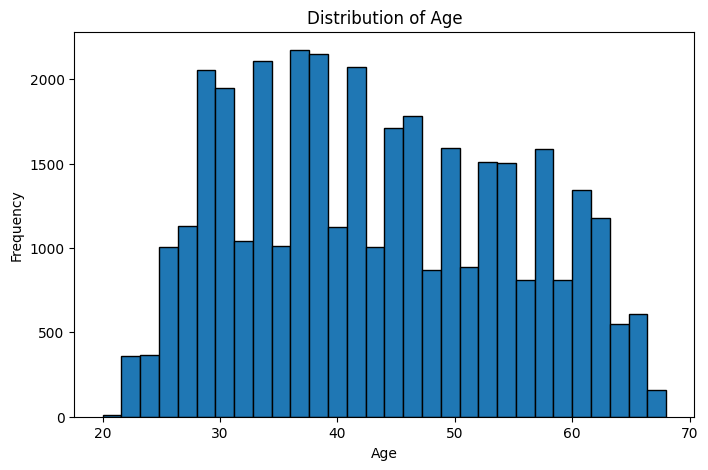

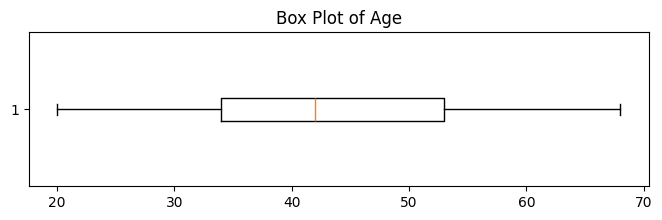


Target-wise Statistics


,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,32166.0,43.382733,11.501073,20.0,34.0,42.0,53.0,68.0
1,4291.0,42.342811,11.540268,21.0,32.0,41.0,52.0,68.0


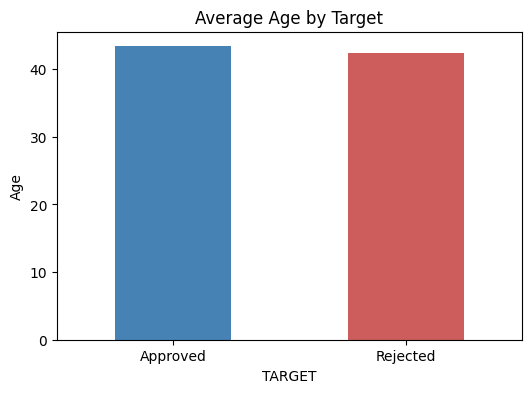

In [22]:
## Analyze Numerical Features

analyze_numerical_feature(final_df, "Age")

* ### **Categorical Feature Analysis**

Categorical variables provide important demographic and socioeconomic information about applicants. A reusable function is created to analyze each categorical feature consistently.

For each feature, the analysis includes:

- Frequency Count
- Percentage Distribution
- Bar Chart
- Target-wise Distribution
- Stacked Bar Chart

In [23]:
def analyze_categorical_feature(data, column):

    print("=" * 70)
    print(f"Feature : {column}")
    print("=" * 70)

    # Frequency Count
    print("\nFrequency Count")
    display(data[column].value_counts())

    # Percentage Distribution
    print("\nPercentage Distribution")
    display(
        (data[column].value_counts(normalize=True) * 100)
        .round(2)
        .rename("Percentage (%)")
    )

    # Bar Chart
    plt.figure(figsize=(8,5))

    data[column].value_counts().plot(
        kind="bar",
        edgecolor="black"
    )

    plt.title(f"{column} Distribution")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.show()

    # Target-wise Distribution
    print("\nTarget-wise Distribution")
    target_table = pd.crosstab(
        data[column],
        data["TARGET"]
    )

    display(target_table)

    # Stacked Bar Chart
    target_table.plot(
        kind="bar",
        stacked=True,
        figsize=(8,5)
    )

    plt.title(f"{column} vs TARGET")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.show()

Feature : CODE_GENDER

Frequency Count


CODE_GENDER
F    24430
M    12027
Name: count, dtype: int64


Percentage Distribution


CODE_GENDER
F    67.01
M    32.99
Name: Percentage (%), dtype: float64

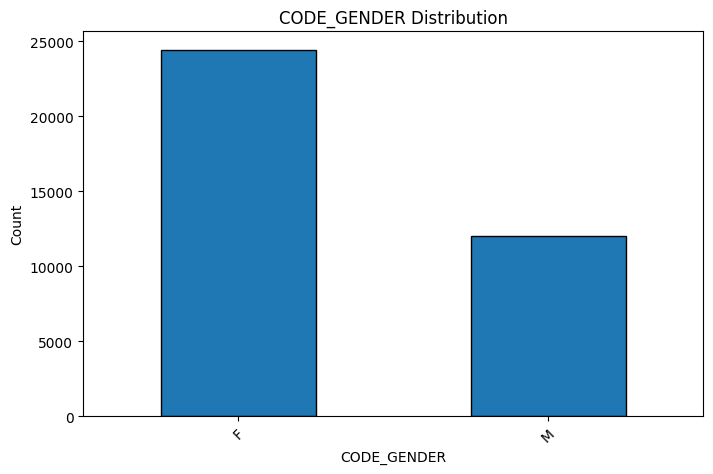


Target-wise Distribution


TARGET,0,1
CODE_GENDER,,
F,21672,2758
M,10494,1533


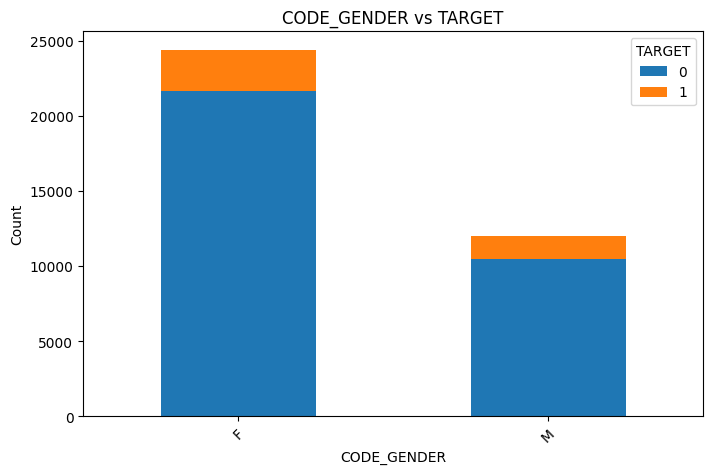

In [24]:
## Analyze Categorical Features

analyze_categorical_feature(final_df, "CODE_GENDER")

Feature : NAME_INCOME_TYPE

Frequency Count


NAME_INCOME_TYPE
Working                 18819
Commercial associate     8490
Pensioner                6152
State servant            2985
Student                    11
Name: count, dtype: int64


Percentage Distribution


NAME_INCOME_TYPE
Working                 51.62
Commercial associate    23.29
Pensioner               16.87
State servant            8.19
Student                  0.03
Name: Percentage (%), dtype: float64

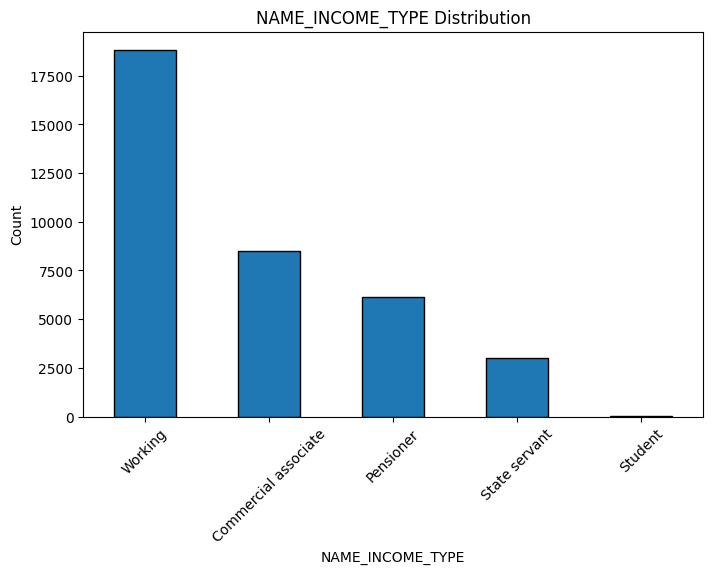


Target-wise Distribution


TARGET,0,1
NAME_INCOME_TYPE,,
Commercial associate,7410,1080
Pensioner,5508,644
State servant,2600,385
Student,10,1
Working,16638,2181


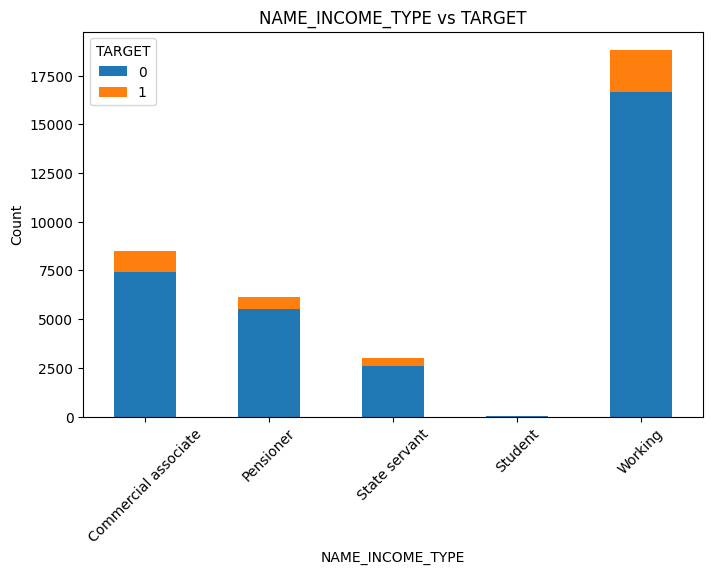

In [25]:
analyze_categorical_feature(final_df, "NAME_INCOME_TYPE")

Feature : NAME_EDUCATION_TYPE

Frequency Count


NAME_EDUCATION_TYPE
Secondary / secondary special    24777
Higher education                  9864
Incomplete higher                 1410
Lower secondary                    374
Academic degree                     32
Name: count, dtype: int64


Percentage Distribution


NAME_EDUCATION_TYPE
Secondary / secondary special    67.96
Higher education                 27.06
Incomplete higher                 3.87
Lower secondary                   1.03
Academic degree                   0.09
Name: Percentage (%), dtype: float64

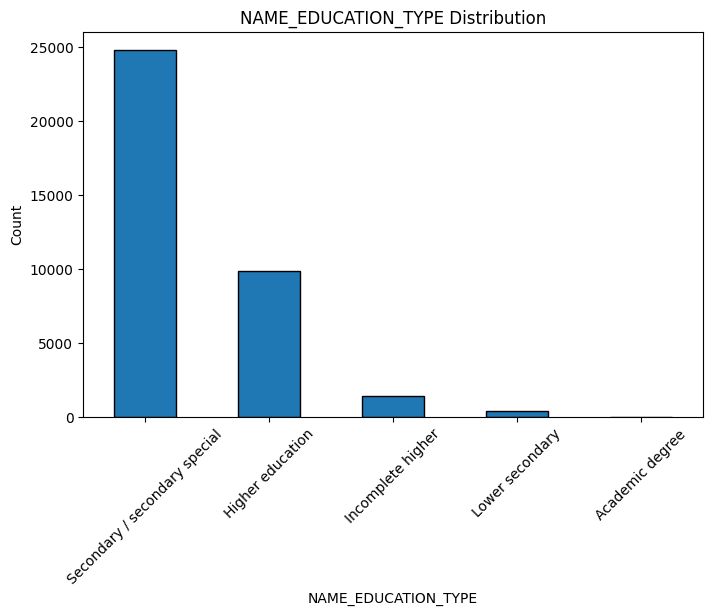


Target-wise Distribution


TARGET,0,1
NAME_EDUCATION_TYPE,,
Academic degree,25,7
Higher education,8716,1148
Incomplete higher,1203,207
Lower secondary,335,39
Secondary / secondary special,21887,2890


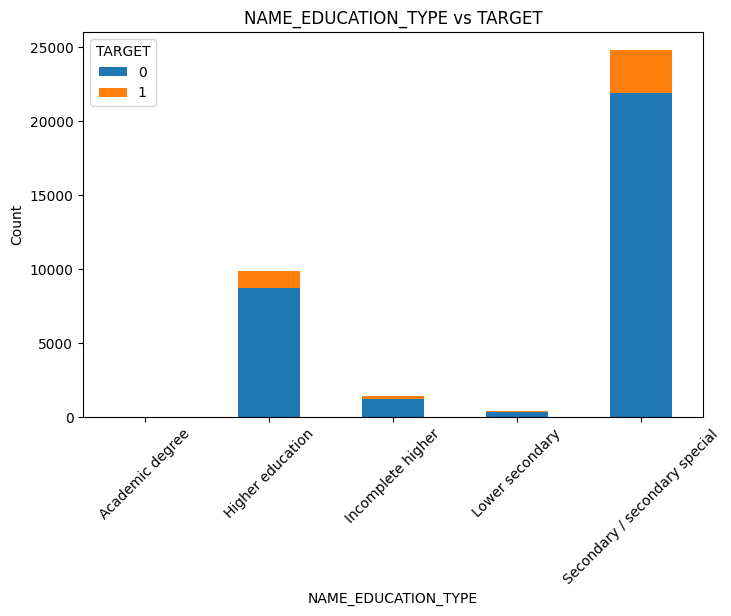

In [26]:
analyze_categorical_feature(final_df, "NAME_EDUCATION_TYPE")

Feature : OCCUPATION_TYPE

Frequency Count


OCCUPATION_TYPE
Laborers                 6211
Core staff               3591
Sales staff              3485
Managers                 3012
Drivers                  2138
High skill tech staff    1383
Accountants              1241
Medicine staff           1207
Cooking staff             655
Security staff            592
Cleaning staff            551
Private service staff     344
Low-skill Laborers        175
Waiters/barmen staff      174
Secretaries               151
HR staff                   85
Realty agents              79
IT staff                   60
Name: count, dtype: int64


Percentage Distribution


OCCUPATION_TYPE
Laborers                 24.71
Core staff               14.29
Sales staff              13.87
Managers                 11.98
Drivers                   8.51
High skill tech staff     5.50
Accountants               4.94
Medicine staff            4.80
Cooking staff             2.61
Security staff            2.36
Cleaning staff            2.19
Private service staff     1.37
Low-skill Laborers        0.70
Waiters/barmen staff      0.69
Secretaries               0.60
HR staff                  0.34
Realty agents             0.31
IT staff                  0.24
Name: Percentage (%), dtype: float64

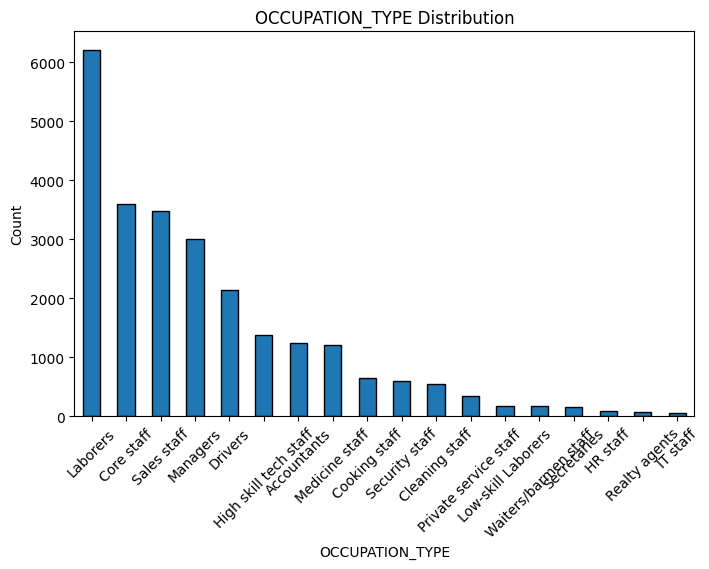


Target-wise Distribution


TARGET,0,1
OCCUPATION_TYPE,,
Accountants,1094,147
Cleaning staff,488,63
Cooking staff,569,86
Core staff,3128,463
Drivers,1874,264
HR staff,71,14
High skill tech staff,1202,181
IT staff,49,11
Laborers,5481,730


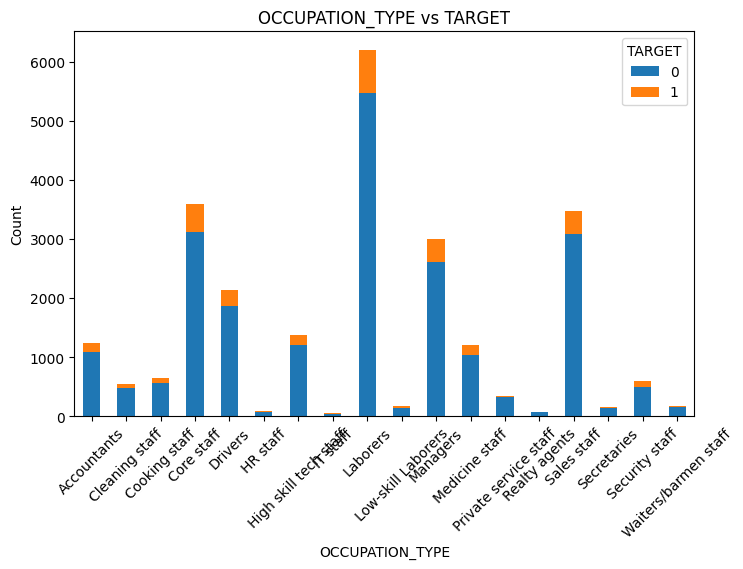

In [27]:
analyze_categorical_feature(final_df, "OCCUPATION_TYPE")

* ### **Correlation Analysis**

In [28]:
# Select numerical columns

numerical_columns = final_df.select_dtypes(include=["int64", "float64"])

numerical_columns.head()


# Correlation matrix

correlation_matrix = numerical_columns.corr()

correlation_matrix

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,TARGET,Employment_Years
ID,1.000000,0.028878,-0.017667,0.056016,-0.038043,NaN,0.079215,0.009879,-0.046979,0.026624,0.003565,-0.026405
CNT_CHILDREN,0.028878,1.000000,0.033691,0.339357,-0.229379,NaN,0.048091,-0.016291,0.015960,0.889114,0.011525,-0.060654
AMT_INCOME_TOTAL,-0.017667,0.033691,1.000000,0.067908,-0.168611,NaN,-0.037746,0.017245,0.086681,0.023750,0.024202,0.019778
DAYS_BIRTH,0.056016,0.339357,0.067908,1.000000,-0.616213,NaN,0.179054,-0.028659,0.105625,0.304020,0.028943,-0.341208
DAYS_EMPLOYED,-0.038043,-0.229379,-0.168611,-0.616213,1.000000,NaN,-0.242869,-0.007233,-0.085648,-0.221241,-0.021566,-0.999990
FLAG_MOBIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_WORK_PHONE,0.079215,0.048091,-0.037746,0.179054,-0.242869,NaN,1.000000,0.311644,-0.034838,0.064527,-0.000149,0.011236
FLAG_PHONE,0.009879,-0.016291,0.017245,-0.028659,-0.007233,NaN,0.311644,1.000000,0.010455,-0.004221,-0.006355,0.048641
FLAG_EMAIL,-0.046979,0.015960,0.086681,0.105625,-0.085648,NaN,-0.034838,0.010455,1.000000,0.014619,0.019658,-0.043795
CNT_FAM_MEMBERS,0.026624,0.889114,0.023750,0.304020,-0.221241,NaN,0.064527,-0.004221,0.014619,1.000000,0.009004,-0.044611


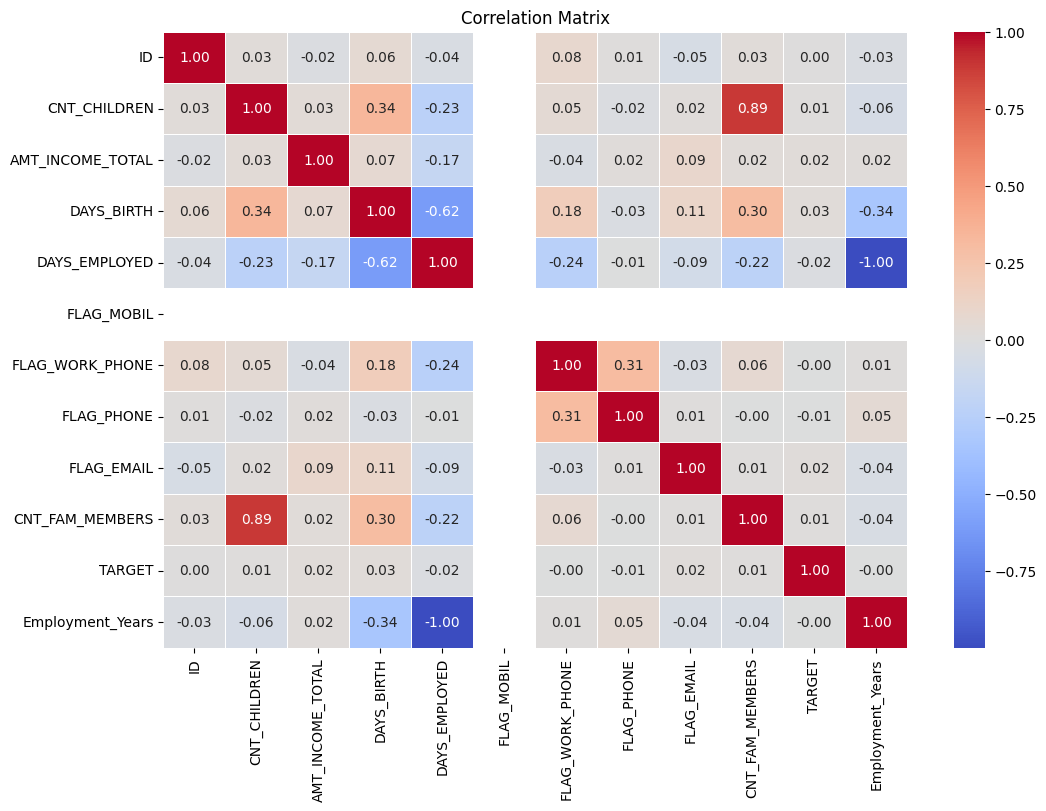

In [29]:
# Correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

In [30]:
# Correlation with target

target_correlation = (
    correlation_matrix["TARGET"]
    .sort_values(ascending=False)
)

target_correlation

TARGET              1.000000
DAYS_BIRTH          0.028943
AMT_INCOME_TOTAL    0.024202
FLAG_EMAIL          0.019658
CNT_CHILDREN        0.011525
CNT_FAM_MEMBERS     0.009004
ID                  0.003565
FLAG_WORK_PHONE    -0.000149
Employment_Years   -0.004609
FLAG_PHONE         -0.006355
DAYS_EMPLOYED      -0.021566
FLAG_MOBIL               NaN
Name: TARGET, dtype: float64

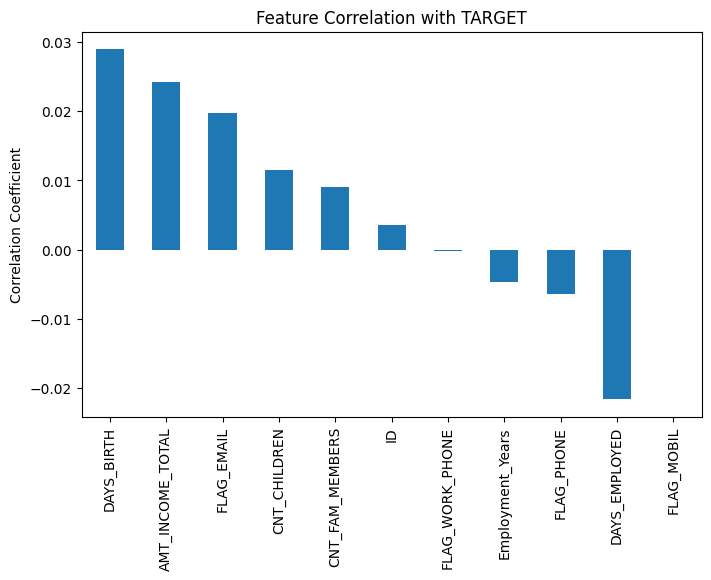

In [31]:
# Visualize feature correlation with target

target_correlation.drop("TARGET").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Feature Correlation with TARGET")
plt.ylabel("Correlation Coefficient")

plt.show()

* ### **Outlier Analysis**

In [32]:
def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    print("="*70)
    print(f"Feature : {column}")
    print("="*70)

    print(f"Q1            : {Q1:.2f}")
    print(f"Q3            : {Q3:.2f}")
    print(f"IQR           : {IQR:.2f}")
    print(f"Lower Bound   : {lower_bound:.2f}")
    print(f"Upper Bound   : {upper_bound:.2f}")
    print(f"Outlier Count : {len(outliers)}")

    return outliers

In [33]:
detect_outliers_iqr(final_df, "AMT_INCOME_TOTAL")

Feature : AMT_INCOME_TOTAL
Q1            : 121500.00
Q3            : 225000.00
IQR           : 103500.00
Lower Bound   : -33750.00
Upper Bound   : 380250.00
Outlier Count : 1529


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,Age,Employment_Years
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,1,32,12.4
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,1,32,12.4
27,5008838,M,N,Y,1,405000.0,Commercial associate,Higher education,Married,House / apartment,...,-2016,1,0,0,0,Managers,3.0,0,32,5.5
28,5008839,M,N,Y,1,405000.0,Commercial associate,Higher education,Married,House / apartment,...,-2016,1,0,0,0,Managers,3.0,0,32,5.5
29,5008840,M,N,Y,1,405000.0,Commercial associate,Higher education,Married,House / apartment,...,-2016,1,0,0,0,Managers,3.0,0,32,5.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36399,5125816,F,Y,N,0,450000.0,Pensioner,Higher education,Married,House / apartment,...,-5521,1,1,1,0,Managers,2.0,1,54,15.1
36413,5135990,F,N,Y,1,585000.0,Commercial associate,Higher education,Single / not married,House / apartment,...,-900,1,0,0,0,Managers,2.0,1,28,2.5
36414,5135991,F,N,Y,1,585000.0,Commercial associate,Higher education,Single / not married,House / apartment,...,-900,1,0,0,0,Managers,2.0,1,28,2.5
36419,5142185,M,Y,Y,2,450000.0,Commercial associate,Higher education,Married,House / apartment,...,-4305,1,1,1,0,Managers,4.0,1,48,11.8


#  Data Preprocessing

In [34]:
# Check missing values

final_df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": final_df.isnull().sum(),
    "Percentage (%)": (
        final_df.isnull().sum() / len(final_df) * 100
    ).round(2)
})

missing_summary[
    missing_summary["Missing Values"] > 0
]

# Remove constant feature
final_df = final_df.drop(columns=["FLAG_MOBIL"])

print("FLAG_MOBIL removed successfully.")

FLAG_MOBIL removed successfully.


In [ ]:


final_df["OCCUPATION_TYPE"] = final_df["OCCUPATION_TYPE"].fillna("Unknown")


final_df["Employment_Years"] = final_df["Employment_Years"].fillna(
    final_df["Employment_Years"].median()
)

In [ ]:
final_df.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
TARGET                 0
Age                    0
Employment_Years       0
dtype: int64

* ### **Feature Selection**

In [ ]:
final_df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL',
       'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'TARGET', 'Age',
       'Employment_Years'],
      dtype='object')

In [ ]:
final_df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL',
       'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'TARGET', 'Age',
       'Employment_Years'],
      dtype='object')

* ###  **Separate Features and Target Variable**

In [ ]:


X = final_df.drop("TARGET", axis=1)

y = final_df["TARGET"]


print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (36457, 19)
Target Vector Shape  : (36457,)


In [40]:
X.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Age,Employment_Years
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,Unknown,2.0,32,12.4
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,Unknown,2.0,32,12.4
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,0,0,0,Security staff,2.0,58,3.1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,Sales staff,1.0,52,8.4
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,Sales staff,1.0,52,8.4


In [41]:
y.head()

0    1
1    1
2    0
3    0
4    0
Name: TARGET, dtype: int64

* ### **Encode Categorical Features**

In [ ]:
categorical_columns = X.select_dtypes(include="object").columns

categorical_columns

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'OCCUPATION_TYPE'],
      dtype='object')

In [ ]:
binary_columns = []
multi_category_columns = []

for column in categorical_columns:

    if X[column].nunique() == 2:
        binary_columns.append(column)
    else:
        multi_category_columns.append(column)

print("Binary Columns:")
print(binary_columns)

print("\nMulti-category Columns:")
print(multi_category_columns)

Binary Columns:
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

Multi-category Columns:
['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


In [44]:
from sklearn.preprocessing import LabelEncoder
import joblib

binary_encoders = {}

for column in binary_columns:

    le = LabelEncoder()

    X[column] = le.fit_transform(X[column])

    binary_encoders[column] = le

joblib.dump(
    binary_encoders,
    "model/binary_encoders.pkl"
)

print("Binary encoders saved successfully.")

Binary encoders saved successfully.


In [ ]:
X = pd.get_dummies(
    X,
    columns=multi_category_columns,
    drop_first=True
)



In [ ]:
X.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,...,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff
0,5008804,1,1,1,0,427500.0,-12005,-4542,1,0,...,False,False,False,False,False,False,False,False,True,False
1,5008805,1,1,1,0,427500.0,-12005,-4542,1,0,...,False,False,False,False,False,False,False,False,True,False
2,5008806,1,1,1,0,112500.0,-21474,-1134,0,0,...,False,False,False,False,False,False,False,True,False,False
3,5008808,0,0,1,0,270000.0,-19110,-3051,0,1,...,False,False,False,False,False,True,False,False,False,False
4,5008809,0,0,1,0,270000.0,-19110,-3051,0,1,...,False,False,False,False,False,True,False,False,False,False


In [47]:
print("Encoded Feature Matrix Shape :", X.shape)

Encoded Feature Matrix Shape : (36457, 49)


In [48]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 49 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   ID                                                 36457 non-null  int64  
 1   CODE_GENDER                                        36457 non-null  int32  
 2   FLAG_OWN_CAR                                       36457 non-null  int32  
 3   FLAG_OWN_REALTY                                    36457 non-null  int32  
 4   CNT_CHILDREN                                       36457 non-null  int64  
 5   AMT_INCOME_TOTAL                                   36457 non-null  float64
 6   DAYS_BIRTH                                         36457 non-null  int64  
 7   DAYS_EMPLOYED                                      36457 non-null  int64  
 8   FLAG_WORK_PHONE                                    36457 non-null  int64  
 9   FLAG_P

* ### **Split the Dataset into Training and Testing Sets**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [50]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (29165, 49)
Testing Features  : (7292, 49)
Training Labels   : (29165,)
Testing Labels    : (7292,)


* ### **Feature Scaling**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape  :", X_test_scaled.shape)

Scaled Training Shape : (29165, 49)
Scaled Testing Shape  : (7292, 49)


* ### **Check Class Imbalance**

Before training machine learning models, the class distribution of the training dataset is analyzed.

If the target classes are highly imbalanced, models may become biased toward the majority class. In such cases, Synthetic Minority Oversampling Technique (SMOTE) is applied to generate synthetic samples for the minority class.

**Note:** SMOTE is applied only to the training dataset to avoid data leakage.

In [ ]:


train_distribution = pd.DataFrame({
    "Count": y_train.value_counts(),
    "Percentage (%)": (y_train.value_counts(normalize=True) * 100).round(2)
})

train_distribution

,Count,Percentage (%)
TARGET,,
0,25732,88.23
1,3433,11.77


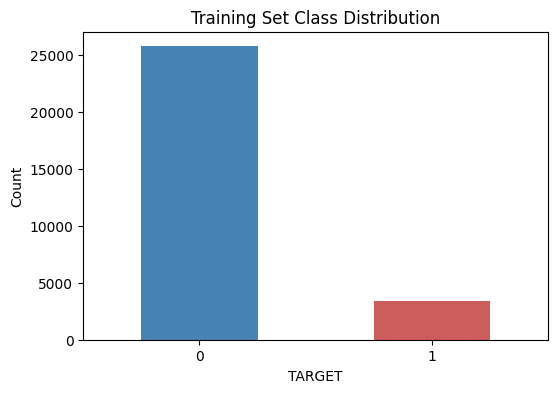

In [ ]:


plt.figure(figsize=(6,4))

y_train.value_counts().plot(
    kind="bar",
    color=["steelblue", "indianred"]
)

plt.title("Training Set Class Distribution")
plt.xlabel("TARGET")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

* ### **Apply SMOTE**

Synthetic Minority Oversampling Technique (SMOTE) generates synthetic samples for the minority class to improve model learning.

SMOTE is applied **only to the training dataset**, while the testing dataset remains unchanged for unbiased evaluation.

In [ ]:
from imblearn.over_sampling import SMOTE



smote = SMOTE(
    random_state=42
)

In [ ]:


X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [57]:
print("Before SMOTE")

print(y_train.value_counts())

print("\nAfter SMOTE")

print(y_train_balanced.value_counts())

Before SMOTE
TARGET
0    25732
1     3433
Name: count, dtype: int64

After SMOTE
TARGET
0    25732
1    25732
Name: count, dtype: int64


# Model Building  


- Logistic Regressio
- Decision Tree
- Random Forest
- XGBoost

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Store model evaluation results
model_results = []

In [59]:
def evaluate_model(model, model_name):

    # Train Model
    model.fit(X_train_balanced, y_train_balanced)

    # Prediction
    y_pred = model.predict(X_test_scaled)

    # Probability Prediction
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    roc_auc = (
        roc_auc_score(y_test, y_prob)
        if y_prob is not None
        else None
    )

    # Save Results
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    if roc_auc is not None:
        print(f"ROC-AUC   : {roc_auc:.4f}")

    

In [60]:
## training model : Logistic Regression



logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

evaluate_model(
    logistic_model,
    "Logistic Regression"
)

Logistic Regression
Accuracy  : 0.5577
Precision : 0.1362
Recall    : 0.5163
F1 Score  : 0.2155
ROC-AUC   : 0.5504


In [61]:
## training model : Decision Tree



decision_tree = DecisionTreeClassifier(
    random_state=42
)

evaluate_model(
    decision_tree,
    "Decision Tree"
)

Decision Tree
Accuracy  : 0.8367
Precision : 0.3413
Recall    : 0.4172
F1 Score  : 0.3755
ROC-AUC   : 0.6549


In [62]:
## training model : Random Forest



random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

evaluate_model(
    random_forest,
    "Random Forest"
)

Random Forest
Accuracy  : 0.8544
Precision : 0.3849
Recall    : 0.3974
F1 Score  : 0.3911
ROC-AUC   : 0.7804


In [63]:
## training model : XGBoost



xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

evaluate_model(
    xgb_model,
    "XGBoost"
)

XGBoost
Accuracy  : 0.8767
Precision : 0.4600
Recall    : 0.2751
F1 Score  : 0.3443
ROC-AUC   : 0.7114


# Model Comparison

* ### **model comparison**

In [64]:

comparison_df = pd.DataFrame(model_results)


comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)


comparison_df.style.background_gradient(cmap="Greens")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.876714,0.460039,0.275058,0.344274,0.711408
1,Random Forest,0.854361,0.384876,0.397436,0.391055,0.780405
2,Decision Tree,0.836670,0.341277,0.417249,0.375459,0.654926
3,Logistic Regression,0.557735,0.136182,0.516317,0.215519,0.550419


* ### **Accuracy Comparison Graph**

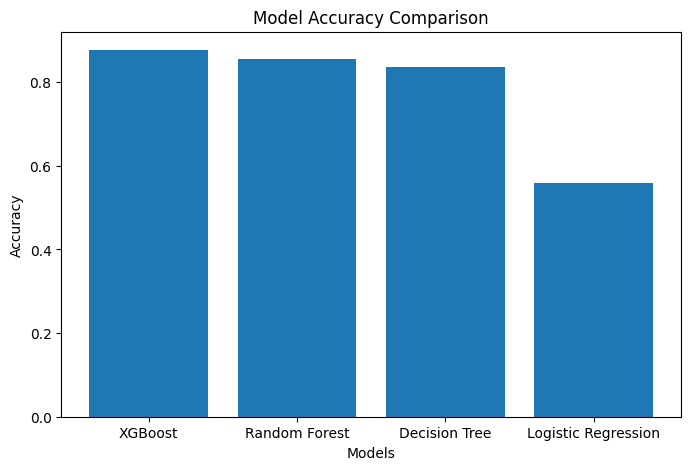

In [65]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=0)

plt.show()

# Best Model Selection

In [66]:
# Display comparison table
comparison_df

# Automatically identify the best model

best_model_name = comparison_df.iloc[0]["Model"]

print(f"Best Model : {best_model_name}")

# Map model names to trained model objects

trained_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "XGBoost": xgb_model
}

best_model = trained_models[best_model_name]

Best Model : XGBoost


# Model Evaluation

* ### **Classification Report**

In [67]:
# Classification Report

y_pred = best_model.predict(X_test_scaled)

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      6434
           1       0.46      0.28      0.34       858

    accuracy                           0.88      7292
   macro avg       0.68      0.62      0.64      7292
weighted avg       0.86      0.88      0.86      7292



* ### **Confusion Matrix**

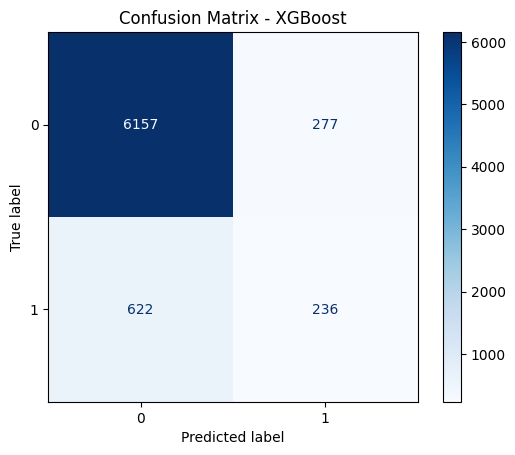

In [68]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()

# Feature Importance

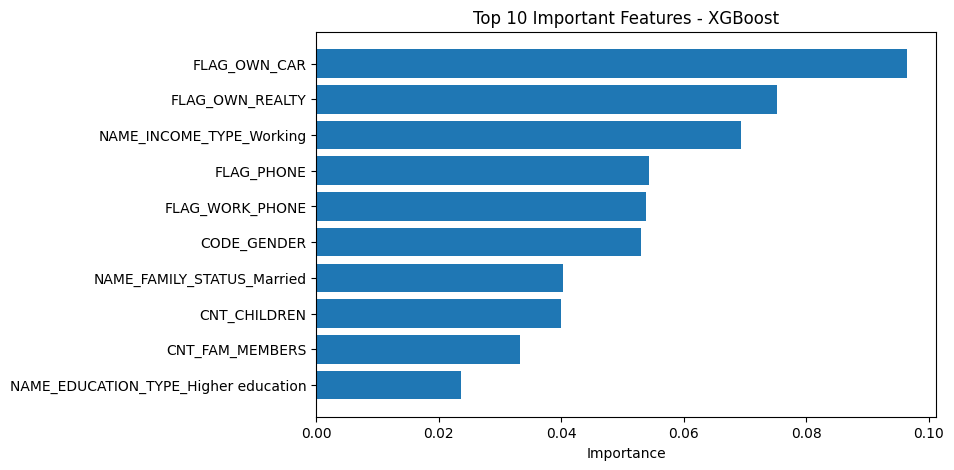

In [69]:
# Feature Importance (Tree-Based Models Only)

if best_model_name in ["Random Forest", "XGBoost"]:

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    importance = (
        importance
        .sort_values(
            by="Importance",
            ascending=False
        )
        .head(10)
    )

    plt.figure(figsize=(8,5))

    plt.barh(
        importance["Feature"],
        importance["Importance"]
    )

    plt.title(f"Top 10 Important Features - {best_model_name}")

    plt.xlabel("Importance")

    plt.gca().invert_yaxis()

    plt.show()

# Save Best Model

In [70]:
import joblib

joblib.dump(
    best_model,
    "model/credit_card_approval_model.pkl"
)

joblib.dump(
    scaler,
    "model/scaler.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "model/feature_columns.pkl"
)

print("Files saved successfully.")

Files saved successfully.


In [71]:
final_df["TARGET"].value_counts()

TARGET
0    32166
1     4291
Name: count, dtype: int64

# Conclusion

The project successfully predicts credit card approval using applicant information and historical credit payment behavior.

The payment history dataset was transformed into a binary approval label and merged with applicant information.

Multiple Machine Learning algorithms were trained and compared, with the best-performing model selected for deployment.

The trained model can assist banks in automating credit card approval decisions, reducing manual effort while improving consistency and scalability.